In [1]:
from constants import users_list, data_path
from lib import spoti, genre_normalizer, plotting, preprocessing, dimensionality_reduction

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import json
import os
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import mean_squared_error
import random
import time
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors as SklearnNearestNeighbors, NeighborhoodComponentsAnalysis
from sklearn.metrics import pairwise_distances
import pickle
import numpy as np
from typing import List, Dict, Tuple, Optional, Any, Callable
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from IPython.display import display, HTML
from recommenders.nearest_neighbours import NearestNeighborsRecommender
from sklearn.model_selection import GridSearchCV
#make scorer
from sklearn.metrics import make_scorer
from recommenders.metrics import similarities_score

# Import data

In [2]:
df = spoti.load_all_tracks(
    base_path=data_path.DATA_PATH,
    users=users_list.USERS,
    top_tracks_affinity_start = {
        "short_term": 1.0,
        "medium_term": 1.0,
        "long_term": 1.0,
    },
    top_tracks_affinity_end = {
        "short_term": 0,
        "medium_term": 0,
        "long_term": 0,
    },
    top_tracks_include_end=False,
    liked_tracks_start_affinity=1.0,
    liked_tracks_end_affinity=0.1,
    liked_tracks_include_endpoint=False,
    load_spotify_tracks=False,
    playlists_affinity=0.2,
)
df

,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
0,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,196426,False,{'isrc': 'USSM12301260'},{'spotify': 'https://open.spotify.com/track/75...,https://api.spotify.com/v1/tracks/75rqqKvzJCGv...,75rqqKvzJCGv2oq9C4yFDt,...,medium_term,1.00,daniel,2023,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
1,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,137533,True,{'isrc': 'USSM12109218'},{'spotify': 'https://open.spotify.com/track/2F...,https://api.spotify.com/v1/tracks/2FYGZDfsAnNs...,2FYGZDfsAnNsrm1gVbyKnG,...,medium_term,0.98,daniel,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
2,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,162906,True,{'isrc': 'USSM12109222'},{'spotify': 'https://open.spotify.com/track/4k...,https://api.spotify.com/v1/tracks/4kroNlz8BTfs...,4kroNlz8BTfswE4M0i3YCh,...,medium_term,0.96,daniel,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
3,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,89749,False,{'isrc': 'USSM12208854'},{'spotify': 'https://open.spotify.com/track/2N...,https://api.spotify.com/v1/tracks/2N3YZ075lq9z...,2N3YZ075lq9z1ObaAiX6l1,...,medium_term,0.94,daniel,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
4,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,174044,False,{'isrc': 'USSM12300114'},{'spotify': 'https://open.spotify.com/track/2S...,https://api.spotify.com/v1/tracks/2SiAcexM2p1y...,2SiAcexM2p1yX6joESbehd,...,medium_term,0.92,daniel,2023,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10230,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,251880,False,{'isrc': 'GBN9Y1100001'},{'spotify': 'https://open.spotify.com/track/3z...,https://api.spotify.com/v1/tracks/3z7dWKRsjDNM...,3z7dWKRsjDNM24ohLKZBnA,...,NaN,0.20,todd,1967,"[rock, rock, rock, rock, rock, rock, rock]",2022-12-30 08:42:31+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
10231,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,193853,False,{'isrc': 'GBLTP1700005'},{'spotify': 'https://open.spotify.com/track/1V...,https://api.spotify.com/v1/tracks/1VofMhhL98pe...,1VofMhhL98pewltVGBSmCW,...,NaN,0.20,todd,2017,"[rock, rock, rock, rock, rock]",2020-08-10 14:53:07+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
10232,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,295493,False,{'isrc': 'GBLTP1700011'},{'spotify': 'https://open.spotify.com/track/0K...,https://api.spotify.com/v1/tracks/0KE7apgczHNY...,0KE7apgczHNYiXIvMUY0Fc,...,NaN,0.20,todd,2017,"[rock, rock, rock, rock, rock]",2020-08-10 14:53:13+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
10233,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,467306,False,{'isrc': 'GBLTP1700014'},{'spotify': 'https://open.spotify.com/track/6v...,https://api.spotify.com/v1/tracks/6vbRA9yAAgIX...,6vbRA9yAAgIXtDlmhyNqPq,...,Na

In [3]:
df.drop_duplicates(subset=["username", "id"], inplace=True)
df.reset_index(drop=True, inplace=True)
df

,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
0,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,196426,False,{'isrc': 'USSM12301260'},{'spotify': 'https://open.spotify.com/track/75...,https://api.spotify.com/v1/tracks/75rqqKvzJCGv...,75rqqKvzJCGv2oq9C4yFDt,...,medium_term,1.00,daniel,2023,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
1,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,137533,True,{'isrc': 'USSM12109218'},{'spotify': 'https://open.spotify.com/track/2F...,https://api.spotify.com/v1/tracks/2FYGZDfsAnNs...,2FYGZDfsAnNsrm1gVbyKnG,...,medium_term,0.98,daniel,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
2,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,162906,True,{'isrc': 'USSM12109222'},{'spotify': 'https://open.spotify.com/track/4k...,https://api.spotify.com/v1/tracks/4kroNlz8BTfs...,4kroNlz8BTfswE4M0i3YCh,...,medium_term,0.96,daniel,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
3,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,89749,False,{'isrc': 'USSM12208854'},{'spotify': 'https://open.spotify.com/track/2N...,https://api.spotify.com/v1/tracks/2N3YZ075lq9z...,2N3YZ075lq9z1ObaAiX6l1,...,medium_term,0.94,daniel,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
4,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,174044,False,{'isrc': 'USSM12300114'},{'spotify': 'https://open.spotify.com/track/2S...,https://api.spotify.com/v1/tracks/2SiAcexM2p1y...,2SiAcexM2p1yX6joESbehd,...,medium_term,0.92,daniel,2023,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5763,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, CH, CW, CY, C...",1,330733,False,{'isrc': 'GBN9X1400200'},{'spotify': 'https://open.spotify.com/track/16...,https://api.spotify.com/v1/tracks/16KX9LfZCjRP...,16KX9LfZCjRPdX84PX1XF9,...,NaN,0.20,todd,2014,"[rock, rock, rock, rock, rock, rock, rock]",2022-01-28 08:37:40+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
5764,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, CH, CW, CY, C...",1,1026853,False,{'isrc': 'GBN9Y1800013'},{'spotify': 'https://open.spotify.com/track/71...,https://api.spotify.com/v1/tracks/715b4AT3ynJy...,715b4AT3ynJyYmtFucyzDu,...,NaN,0.20,todd,1977,"[rock, rock, rock, rock, rock, rock, rock]",2022-09-25 09:41:36+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
5765,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,251880,False,{'isrc': 'GBN9Y1100001'},{'spotify': 'https://open.spotify.com/track/3z...,https://api.spotify.com/v1/tracks/3z7dWKRsjDNM...,3z7dWKRsjDNM24ohLKZBnA,...,NaN,0.20,todd,1967,"[rock, rock, rock, rock, rock, rock, rock]",2022-12-30 08:42:31+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
5766,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,295493,False,{'isrc': 'GBLTP1700011'},{'spotify': 'https://open.spotify.com/track/0K...,https://api.spotify.com/v1/tracks/0KE7apgczHNY...,0KE7apgc

# Distribution

/var/folders/jy/ts_mdpfs04d36f2cz44nqbl00000gn/T/ipykernel_2494/920180189.py:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plotting.plot_feature_distribution(df, spoti.NUMERICAL_FEATURES, cols=5, rows=3).show()


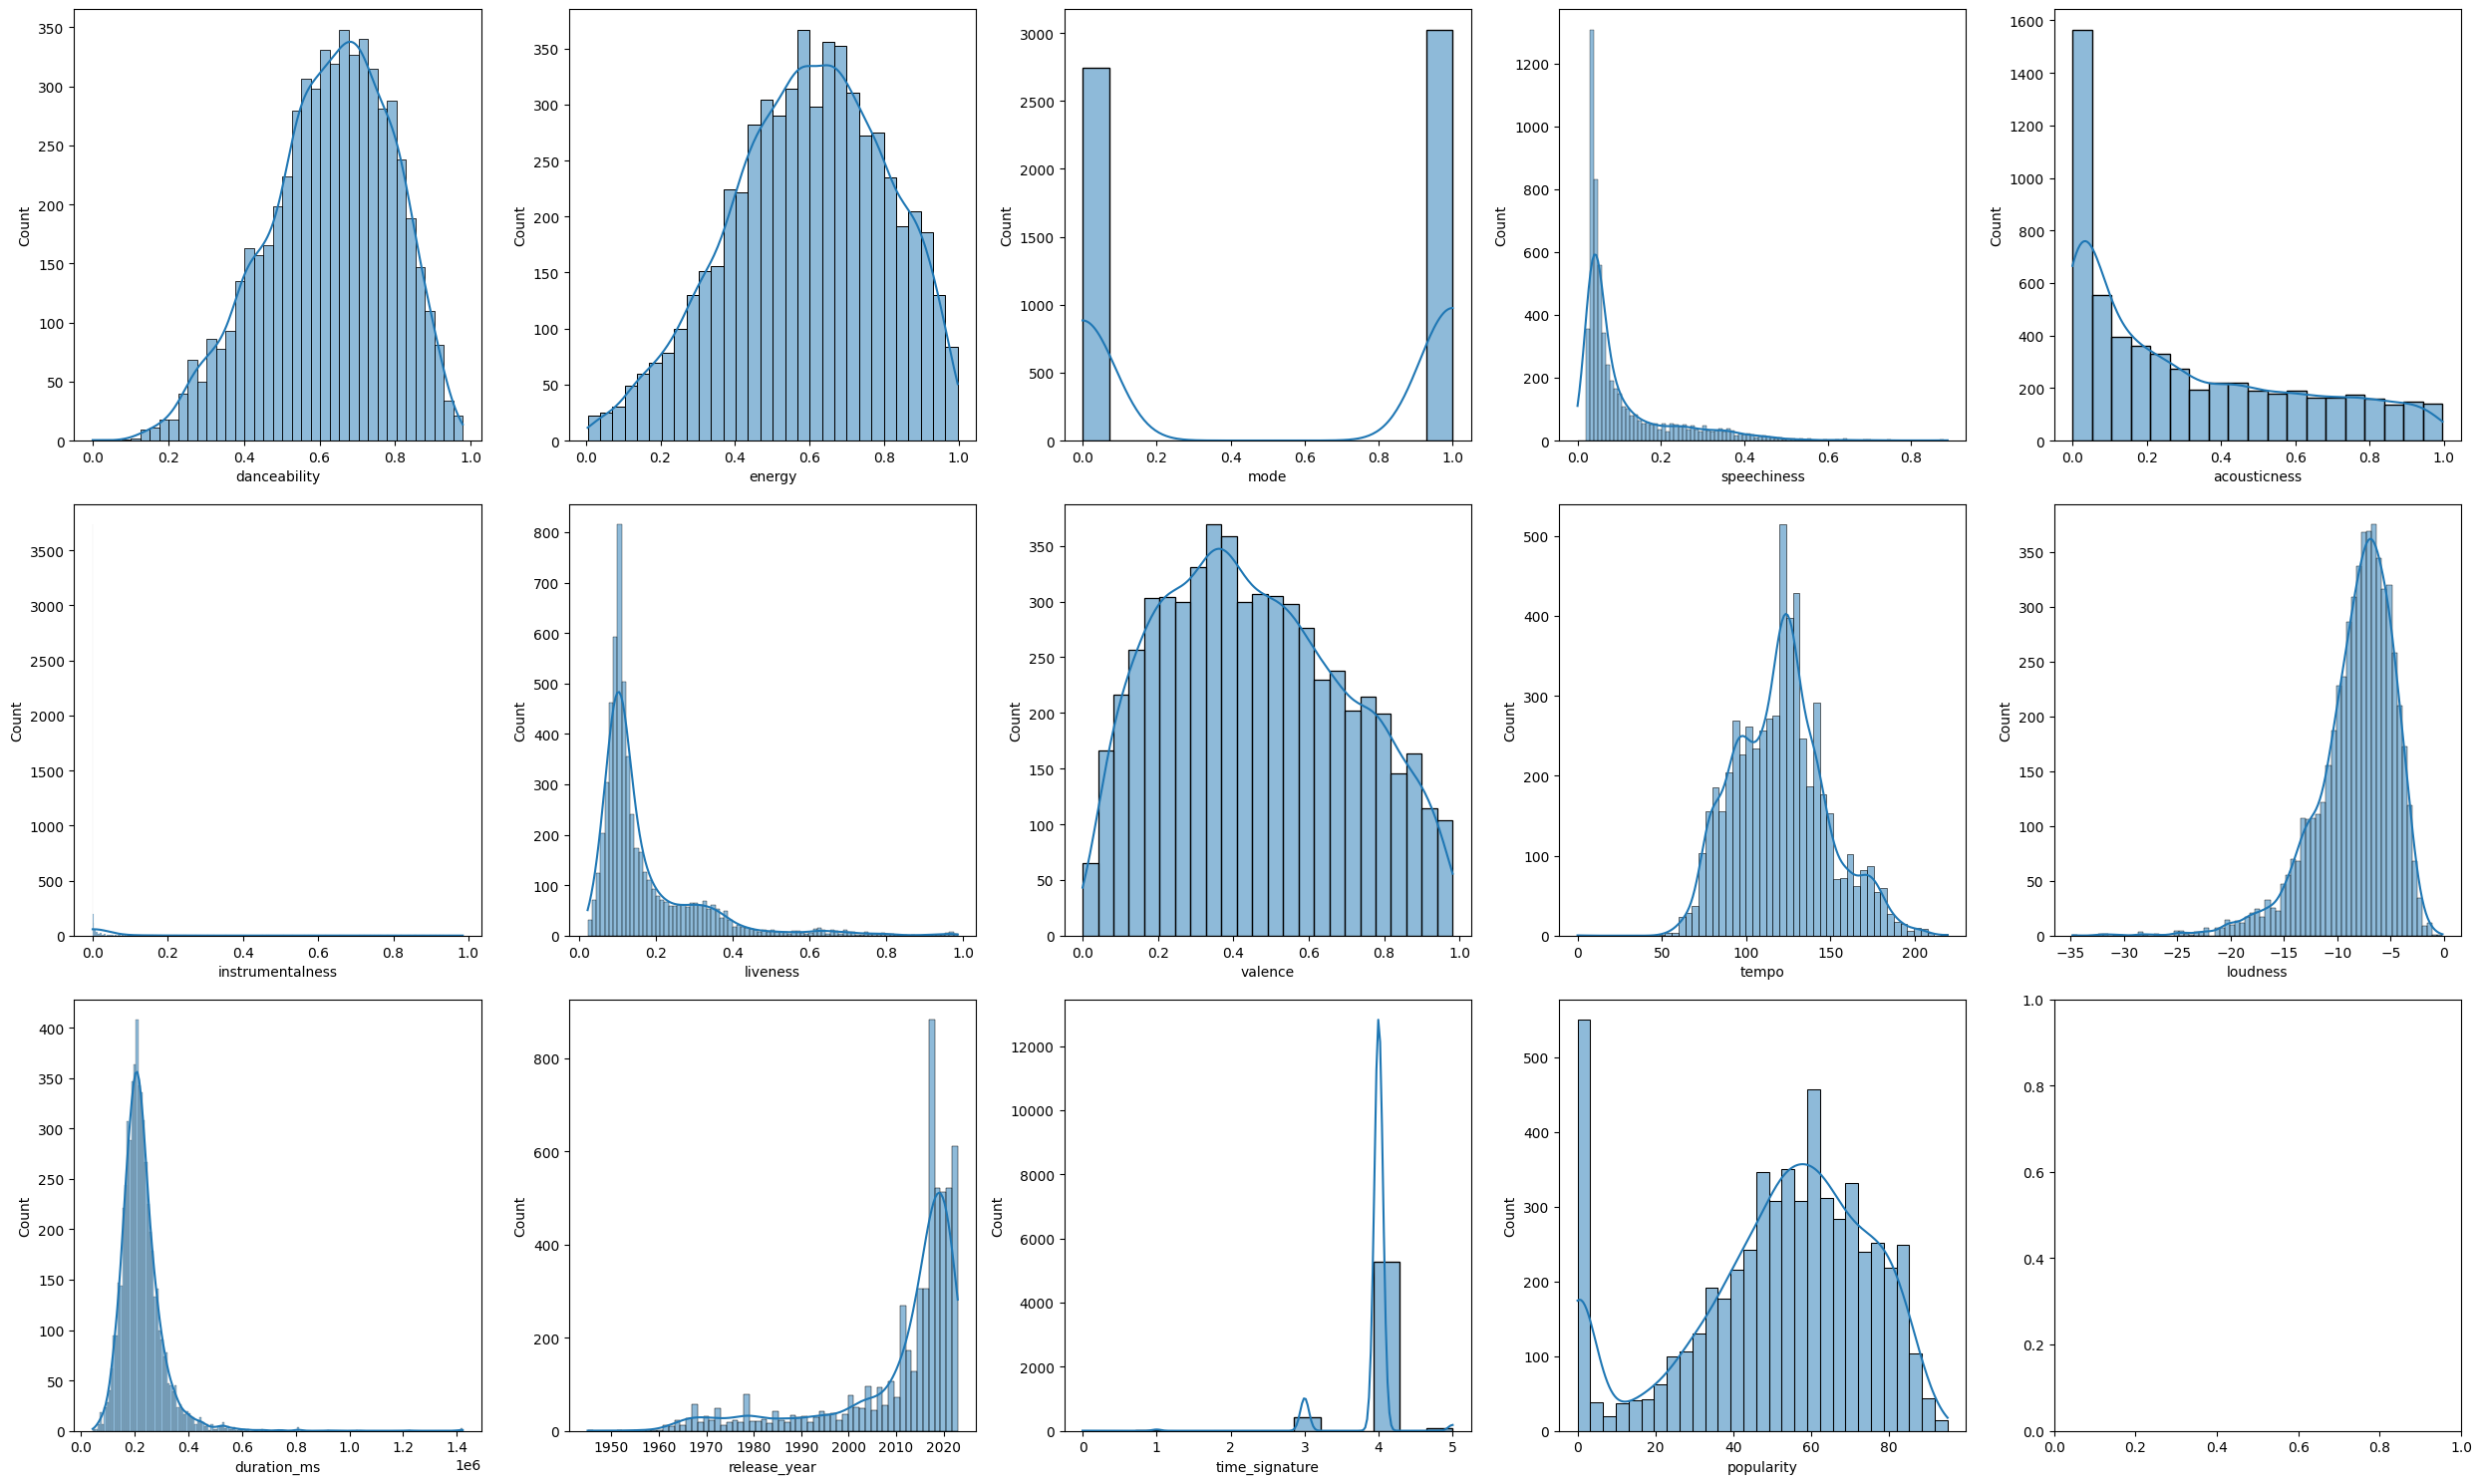

In [4]:
plotting.plot_feature_distribution(df, spoti.NUMERICAL_FEATURES, cols=5, rows=3).show()

/var/folders/jy/ts_mdpfs04d36f2cz44nqbl00000gn/T/ipykernel_2494/2962548486.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plotting.plot_feature_distribution(df, spoti.NUMERICAL_FEATURES, cols=5, rows=3).show()


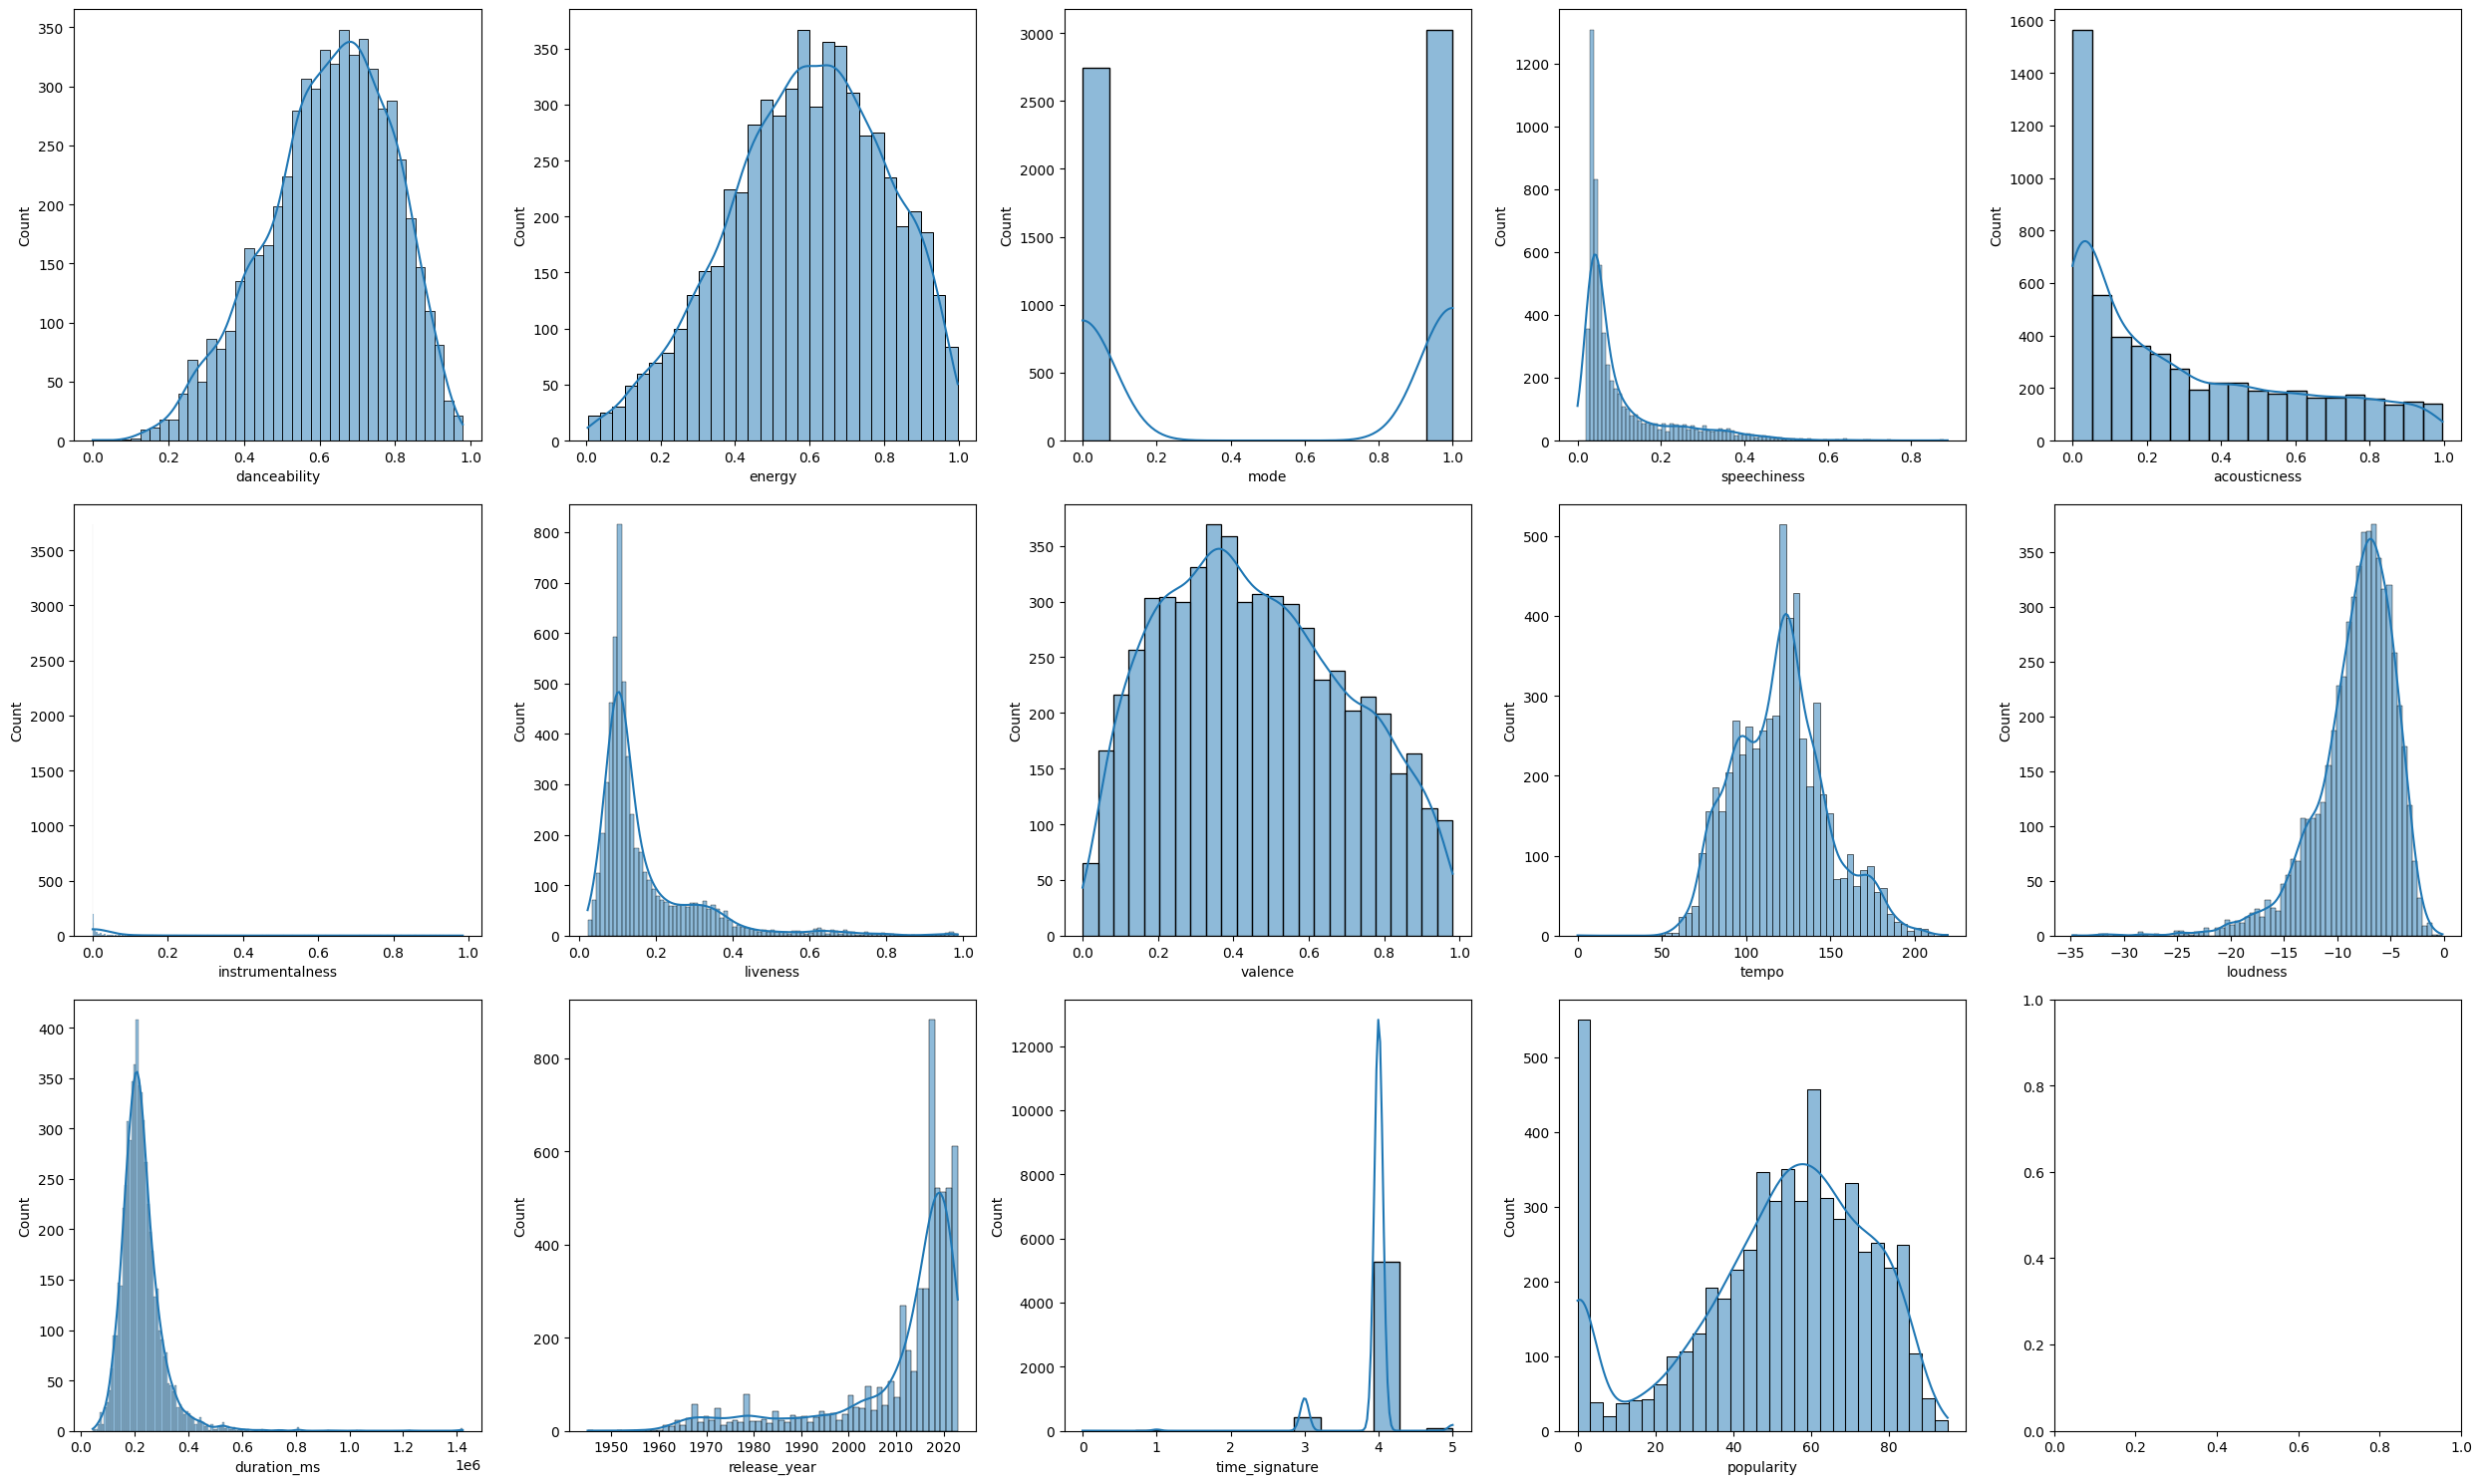

In [5]:
# Remove outliers based on IQR
df_train = preprocessing.remove_outliers_iqr(df, spoti.NUMERICAL_FEATURES, quantile=0.25, threshold=1.5)
plotting.plot_feature_distribution(df, spoti.NUMERICAL_FEATURES, cols=5, rows=3).show()

In [6]:
plotting.plot_genres(df["genres"])

In [7]:
plotting.plot_genres(df["normalized_genres"])

In [8]:
sparsity, users_count, items_count, interactions_count = preprocessing.compute_sparsity(df, "username", "id")
print(f"After filtering, there is {len(users_count)} users, {len(items_count)} items and {len(interactions_count)} interactions, so the sparsity is {sparsity*100:.2f}%.")

After filtering, there is 7 users, 5395 items and 5768 interactions, so the sparsity is 15.27%.


In [9]:
display(users_count)
shuffled_users_df = preprocessing.permute_users(users_count=users_count, seed=42)
display(shuffled_users_df)

username
larry       2387
daniel      1020
sean         709
timothy      707
meagan       434
virginia     274
todd         237
Name: count, dtype: int64

,count,old_index
username,,
larry,2387,larry
daniel,1020,daniel
virginia,274,virginia
sean,709,sean
meagan,434,meagan
timothy,707,timothy
todd,237,todd


In [10]:
shuffled_users_df = preprocessing.permute_users(users_count=users_count, seed=42)
shuffled_users_df

,count,old_index
username,,
larry,2387,larry
daniel,1020,daniel
virginia,274,virginia
sean,709,sean
meagan,434,meagan
timothy,707,timothy
todd,237,todd


In [11]:
train_df_user, val_df_users, test_df_users = preprocessing.split_users_train_validation_test(df_users_shuffled=shuffled_users_df, validation_percentage=0.3, test_percentage=0.2)
print("Original data:")
display(shuffled_users_df)
print("Train data:")
display(train_df_user)
print("Validation data:")
display(val_df_users)
print("Test data:")
display(test_df_users)

Original data:


,count,old_index
username,,
larry,2387,larry
daniel,1020,daniel
virginia,274,virginia
sean,709,sean
meagan,434,meagan
timothy,707,timothy
todd,237,todd


Train data:


,count,old_index
username,,
larry,2387,larry
daniel,1020,daniel
virginia,274,virginia


Validation data:


,count,old_index
username,,
sean,709,sean
meagan,434,meagan


Test data:


,count,old_index
username,,
timothy,707,timothy
todd,237,todd


In [12]:
train_df = df[df["username"].isin(train_df_user.index)]
# train_df["username"] = train_df["username"].cat.remove_unused_categories()
# train_df["id"] = train_df["id"].cat.remove_unused_categories()
print("Train data:")
display(train_df)

val_df_train, val_df_test = preprocessing.populate_train_test_dataframes(
    df=df,
    selected_users=val_df_users,
    test_percentage=0.5,
    min_items_threshold=2,
)
# val_df_train["username"] = val_df_train["username"].cat.remove_unused_categories()
# val_df_test["username"] = val_df_test["username"].cat.remove_unused_categories()
# val_df_train["id"] = val_df_train["id"].cat.remove_unused_categories()
# val_df_test["id"] = val_df_test["id"].cat.remove_unused_categories()
print("Validation train data:")
display(val_df_train)
print("Validation test data:")
display(val_df_test)

test_df_train, test_df_test = preprocessing.populate_train_test_dataframes(
    df=df,
    selected_users=test_df_users,
    test_percentage=0.5,
    min_items_threshold=2,
)
# test_df_train["username"] = test_df_train["username"].cat.remove_unused_categories()
# test_df_test["username"] = test_df_test["username"].cat.remove_unused_categories()
# test_df_train["id"] = test_df_train["id"].cat.remove_unused_categories()
# test_df_test["id"] = test_df_test["id"].cat.remove_unused_categories()
print("Test train data:")
display(test_df_train)
print("Test test data:")
display(test_df_test)

Train data:


,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
0,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,196426,False,{'isrc': 'USSM12301260'},{'spotify': 'https://open.spotify.com/track/75...,https://api.spotify.com/v1/tracks/75rqqKvzJCGv...,75rqqKvzJCGv2oq9C4yFDt,...,medium_term,1.00,daniel,2023,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
1,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,137533,True,{'isrc': 'USSM12109218'},{'spotify': 'https://open.spotify.com/track/2F...,https://api.spotify.com/v1/tracks/2FYGZDfsAnNs...,2FYGZDfsAnNsrm1gVbyKnG,...,medium_term,0.98,daniel,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
2,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,162906,True,{'isrc': 'USSM12109222'},{'spotify': 'https://open.spotify.com/track/4k...,https://api.spotify.com/v1/tracks/4kroNlz8BTfs...,4kroNlz8BTfswE4M0i3YCh,...,medium_term,0.96,daniel,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
3,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,89749,False,{'isrc': 'USSM12208854'},{'spotify': 'https://open.spotify.com/track/2N...,https://api.spotify.com/v1/tracks/2N3YZ075lq9z...,2N3YZ075lq9z1ObaAiX6l1,...,medium_term,0.94,daniel,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
4,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,174044,False,{'isrc': 'USSM12300114'},{'spotify': 'https://open.spotify.com/track/2S...,https://api.spotify.com/v1/tracks/2SiAcexM2p1y...,2SiAcexM2p1yX6joESbehd,...,medium_term,0.92,daniel,2023,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3676,"{'album_type': 'compilation', 'artists': [{'ex...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,442525,False,{'isrc': 'DEEC31850079'},{'spotify': 'https://open.spotify.com/track/0u...,https://api.spotify.com/v1/tracks/0uKKDJ3L2ayy...,0uKKDJ3L2ayyhrrhT4iI9v,...,NaN,0.20,virginia,2018,"[electronic, electronic, electronic]",2020-06-04 13:41:17+00:00,False,True,ikjhkfpoa7sf4tauwxjcc1c2q,3FFvJVCiNxq2qsd6rqxt1a
3677,"{'album_type': 'single', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,390432,False,{'isrc': 'DEU671501764'},{'spotify': 'https://open.spotify.com/track/1c...,https://api.spotify.com/v1/tracks/1cHILp7cZPPu...,1cHILp7cZPPu5y4IgC2l0l,...,NaN,0.20,virginia,2015,"[electronic, electronic, electronic, electroni...",2020-06-04 13:41:33+00:00,False,True,ikjhkfpoa7sf4tauwxjcc1c2q,3FFvJVCiNxq2qsd6rqxt1a
3678,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,320362,False,{'isrc': 'DEPL91591066'},{'spotify': 'https://open.spotify.com/track/75...,https://api.spotify.com/v1/tracks/75igUfj0JlKM...,75igUfj0JlKM8TfUrkgoIT,...,NaN,0.20,virginia,2015,"[electronic, electronic, electronic, electroni...",2020-06-04 13:42:09+00:00,False,True,ikjhkfpoa7sf4tauwxjcc1c2q,3FFvJVCiNxq2qsd6rqxt1a
3679,"{'album_type': 'compilation', 'artists': [{'ex...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,432116,False,{'isrc': 'DEEC31850084'},{'spotify': 'https://open.spotify.com/track/5l...,https://api.spotify.com/v1/tracks/5lTHp

Validation train data:


,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
3681,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,162637,False,{'isrc': 'QZDYA1800087'},{'spotify': 'https://open.spotify.com/track/5w...,https://api.spotify.com/v1/tracks/5ww2BF9slyYg...,5ww2BF9slyYgNOk37BlC4u,...,medium_term,1.00,meagan,2022,"[pop, reggaeton, reggaeton colombiano, spanish...",NaT,NaN,NaN,NaN,NaN
3683,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,209995,False,{'isrc': 'FR9W12226832'},{'spotify': 'https://open.spotify.com/track/0n...,https://api.spotify.com/v1/tracks/0nhc1MSnJX72...,0nhc1MSnJX72PEP623DQ0J,...,medium_term,0.96,meagan,2022,[],NaT,NaN,NaN,NaN,NaN
3684,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,229906,False,{'isrc': 'CHD542300011'},{'spotify': 'https://open.spotify.com/track/4p...,https://api.spotify.com/v1/tracks/4pzBPEVPTekg...,4pzBPEVPTekgmjbn5qjcSP,...,medium_term,0.94,meagan,2023,[indie],NaT,NaN,NaN,NaN,NaN
3687,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CH, C...",1,209106,False,{'isrc': 'GBUM71103440'},{'spotify': 'https://open.spotify.com/track/7n...,https://api.spotify.com/v1/tracks/7nhWtCc3v6Ve...,7nhWtCc3v6Vem80gYPlppQ,...,medium_term,0.88,meagan,1982,"[rock, rock, rock]",NaT,NaN,NaN,NaN,NaN
3688,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CH, C...",2,247986,False,{'isrc': 'GBUM72202684'},{'spotify': 'https://open.spotify.com/track/4d...,https://api.spotify.com/v1/tracks/4dLzlXPvmRMD...,4dLzlXPvmRMDE5w4IBSTD6,...,medium_term,0.86,meagan,2022,"[rock, rock, rock]",NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4811,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,235173,False,{'isrc': 'CAA359300084'},{'spotify': 'https://open.spotify.com/track/31...,https://api.spotify.com/v1/tracks/31v2AQlx4pDI...,31v2AQlx4pDI7kmnLxBkem,...,NaN,0.20,sean,1993,"[rock, pop, grunge]",2020-09-06 14:43:51+00:00,False,True,2024rpz,60LLfcAgSHTbpiQNnhTuWT
4814,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,219010,False,{'isrc': 'PTES10300102'},{'spotify': 'https://open.spotify.com/track/7h...,https://api.spotify.com/v1/tracks/7hMyxHOskG0E...,7hMyxHOskG0Eq2cHQ52WnQ,...,NaN,0.20,sean,2003,[pop],2020-09-10 00:23:49+00:00,False,True,11149177889,60LLfcAgSHTbpiQNnhTuWT
4817,"{'album_type': 'compilation', 'artists': [{'ex...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CL, CO, CR, CY, C...",1,144480,False,{'isrc': 'FR3V90500001'},{'spotify': 'https://open.spotify.com/track/4F...,https://api.spotify.com/v1/tracks/4FpgfNRPPlN3...,4FpgfNRPPlN3GxrlNeuUIV,...,NaN,0.20,sean,2016,[french],2020-09-10 00:58:32+00:00,False,True,unemortelle,60LLfcAgSHTbpiQNnhTuWT
4818,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CL, CO, CR, CY, C...",2,194120,False,{'isrc': 'FR9W11503621'},{'spotify': 'https://open.spotify.com/track/4u...,https://api.spotify.com/v1/tracks/4u2dQmcZaFAu...,4u2dQmcZaFAu0fKXGmIf96,...,NaN,0.20,sean,2015,[pop],2020-09-10 01:08:42+00:00,False,True,unemortelle,60LLfcAgSHTbpiQNnhTuWT


Validation test data:


,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
3682,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,195001,False,{'isrc': 'FR9W12118513'},{'spotify': 'https://open.spotify.com/track/57...,https://api.spotify.com/v1/tracks/57S7JmztNeYb...,57S7JmztNeYbGzpW3F6nNu,...,medium_term,0.98,meagan,2021,[],NaT,NaN,NaN,NaN,NaN
3685,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,129199,False,{'isrc': 'DED830162802'},{'spotify': 'https://open.spotify.com/track/5q...,https://api.spotify.com/v1/tracks/5qEZvemAAeZ8...,5qEZvemAAeZ8E9KmyyGaLe,...,medium_term,0.92,meagan,1996,"[metal, metal, metal, metal, metal, metal, roc...",NaT,NaN,NaN,NaN,NaN
3686,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AT, AU, BE, BG, BH, CA, CH, CY, CZ, D...",1,138013,False,{'isrc': 'NLF711403495'},{'spotify': 'https://open.spotify.com/track/42...,https://api.spotify.com/v1/tracks/4255amV4enzl...,4255amV4enzl28KAn16rUO,...,medium_term,0.90,meagan,2016,"[electronic, electronic, pop, electronic]",NaT,NaN,NaN,NaN,NaN
3689,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,167356,False,{'isrc': 'DEA622202192'},{'spotify': 'https://open.spotify.com/track/7o...,https://api.spotify.com/v1/tracks/7oQepKHmXDaP...,7oQepKHmXDaPC3rgeLRvQu,...,medium_term,0.84,meagan,2023,"[pop, rock]",NaT,NaN,NaN,NaN,NaN
3692,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,153088,False,{'isrc': 'ITD542001656'},{'spotify': 'https://open.spotify.com/track/1U...,https://api.spotify.com/v1/tracks/1Uf9cT6BIRr3...,1Uf9cT6BIRr333uIZ64H0T,...,medium_term,0.78,meagan,2020,[classical/opera],NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4816,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,236546,False,{'isrc': 'ITB268300025'},{'spotify': 'https://open.spotify.com/track/2S...,https://api.spotify.com/v1/tracks/2S7RApTsKT0C...,2S7RApTsKT0CtYojYq2cKz,...,NaN,0.20,sean,1983,[pop],2020-09-10 00:51:50+00:00,False,True,unemortelle,60LLfcAgSHTbpiQNnhTuWT
4820,"{'album_type': 'single', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,162864,False,{'isrc': 'USAT21904486'},{'spotify': 'https://open.spotify.com/track/6r...,https://api.spotify.com/v1/tracks/6rVNnvyNeibt...,6rVNnvyNeibts1uOqdSNIw,...,NaN,0.20,sean,2019,"[pop, pop]",2020-09-11 01:47:57+00:00,False,True,unemortelle,60LLfcAgSHTbpiQNnhTuWT
4821,"{'album_type': 'single', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,143791,True,{'isrc': 'USAT21903333'},{'spotify': 'https://open.spotify.com/track/6d...,https://api.spotify.com/v1/tracks/6dPyzkyZwoj9...,6dPyzkyZwoj9LqjQXOFdVv,...,NaN,0.20,sean,2019,"[pop, rap]",2020-09-11 01:48:02+00:00,False,True,unemortelle,60LLfcAgSHTbpiQNnhTuWT
4822,"{'album_type': 'single', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,210000,False,{'isrc': 'FR6V80299795'},{'spotify': 'https://open.spotify.com/track/0P...,https://api.spotify.com/v1/tracks/0Psg9I37jSzo...,0Psg9I37jSzox4p7caEWCN,...,NaN,0.20,sean,2012,[rap],2020-09-11 01:49:00+00:00,False,True,unemortelle,60LLfcAgSHTbpiQ

Test train data:


,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
4825,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,223106,True,{'isrc': 'FR9W11814775'},{'spotify': 'https://open.spotify.com/track/7j...,https://api.spotify.com/v1/tracks/7jawKXg08iaO...,7jawKXg08iaOUOD7lFg0wY,...,medium_term,0.98,timothy,2018,"[rap, pop]",NaT,NaN,NaN,NaN,NaN
4826,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,315773,True,{'isrc': 'USRC11802276'},{'spotify': 'https://open.spotify.com/track/3o...,https://api.spotify.com/v1/tracks/3oHkMCVJyOcj...,3oHkMCVJyOcjg5FhfLc2Rq,...,medium_term,0.96,timothy,2018,"[rap, rap, rap, rap]",NaT,NaN,NaN,NaN,NaN
4833,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,119183,True,{'isrc': 'QZPLS2197154'},{'spotify': 'https://open.spotify.com/track/36...,https://api.spotify.com/v1/tracks/363mqittn6QH...,363mqittn6QH7w5qMmsEB0,...,medium_term,0.82,timothy,2021,"[rap, rap, rap, pop]",NaT,NaN,NaN,NaN,NaN
4834,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,223255,True,{'isrc': 'FR4DW1802310'},{'spotify': 'https://open.spotify.com/track/4L...,https://api.spotify.com/v1/tracks/4LSaSPJi2drQ...,4LSaSPJi2drQb3xL7VXKKb,...,medium_term,0.80,timothy,2018,"[rap, rap, pop, rap]",NaT,NaN,NaN,NaN,NaN
4835,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,206896,True,{'isrc': 'FR4DW1802300'},{'spotify': 'https://open.spotify.com/track/3B...,https://api.spotify.com/v1/tracks/3Bc8gFjMtqUh...,3Bc8gFjMtqUhuF5ZQ8GiQl,...,medium_term,0.78,timothy,2018,"[rap, rap, pop, rap]",NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5761,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, CH, CW, CY, C...",1,392573,False,{'isrc': 'GBN9X1400068'},{'spotify': 'https://open.spotify.com/track/6F...,https://api.spotify.com/v1/tracks/6FOHrTobTT0Y...,6FOHrTobTT0YXQtQFT4zjk,...,NaN,0.20,todd,2014,"[rock, rock, rock, rock, rock, rock, rock]",2020-11-04 17:12:10+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
5762,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,273693,False,{'isrc': 'GBN9Y1100072'},{'spotify': 'https://open.spotify.com/track/4u...,https://api.spotify.com/v1/tracks/4uxrLzUlWG71...,4uxrLzUlWG71UR4jN1G4cL,...,NaN,0.20,todd,1972,"[rock, rock, rock, rock, rock, rock, rock]",2021-12-18 12:41:00+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
5765,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,251880,False,{'isrc': 'GBN9Y1100001'},{'spotify': 'https://open.spotify.com/track/3z...,https://api.spotify.com/v1/tracks/3z7dWKRsjDNM...,3z7dWKRsjDNM24ohLKZBnA,...,NaN,0.20,todd,1967,"[rock, rock, rock, rock, rock, rock, rock]",2022-12-30 08:42:31+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
5766,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,295493,False,{'isrc': 'GBLTP1700011'},{'spotify': 'https://open.spotify.com/track/0K...,https://api.spotify.com/v1/tracks/0KE7apgczHNY

Test test data:


,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
4824,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,168773,True,{'isrc': 'FR9W11814772'},{'spotify': 'https://open.spotify.com/track/1G...,https://api.spotify.com/v1/tracks/1GYQSUVMQXDa...,1GYQSUVMQXDajxHG3AOi9o,...,medium_term,1.00,timothy,2018,"[rap, pop]",NaT,NaN,NaN,NaN,NaN
4827,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,169560,True,{'isrc': 'USRC11101084'},{'spotify': 'https://open.spotify.com/track/3t...,https://api.spotify.com/v1/tracks/3tTpvK7QgjjQ...,3tTpvK7QgjjQCKGnHt5xn3,...,medium_term,0.94,timothy,2011,"[rap, rap, rap, rap]",NaT,NaN,NaN,NaN,NaN
4828,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,205040,True,{'isrc': 'USRC11800930'},{'spotify': 'https://open.spotify.com/track/7y...,https://api.spotify.com/v1/tracks/7ycWLEP1GsNj...,7ycWLEP1GsNjVvcjawXz3z,...,medium_term,0.92,timothy,2018,"[rap, rap, rap, rap]",NaT,NaN,NaN,NaN,NaN
4829,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,173711,True,{'isrc': 'FR7O51800280'},{'spotify': 'https://open.spotify.com/track/4V...,https://api.spotify.com/v1/tracks/4VzSIVvtfvyi...,4VzSIVvtfvyiqMlIZUlje0,...,medium_term,0.90,timothy,2019,"[rap, pop, rap, rap]",NaT,NaN,NaN,NaN,NaN
4830,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,177876,True,{'isrc': 'FR7O51900130'},{'spotify': 'https://open.spotify.com/track/4a...,https://api.spotify.com/v1/tracks/4a4cTUsFiyPN...,4a4cTUsFiyPN8jaHt2xf18,...,medium_term,0.88,timothy,2019,"[rap, pop, rap, rap]",NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5754,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, CH, CW, CY, C...",1,379280,False,{'isrc': 'GBN9X1100019'},{'spotify': 'https://open.spotify.com/track/0n...,https://api.spotify.com/v1/tracks/0nZVzNtcrXnx...,0nZVzNtcrXnxVaXiB5bfO4,...,NaN,0.20,todd,1994,"[rock, rock, rock, rock, rock, rock, rock]",2020-08-10 14:48:49+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
5755,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, CH, CW, CY, C...",1,511013,False,{'isrc': 'GBN9X1100022'},{'spotify': 'https://open.spotify.com/track/23...,https://api.spotify.com/v1/tracks/236mI0lz8JdQ...,236mI0lz8JdQjlmijARSwY,...,NaN,0.20,todd,1994,"[rock, rock, rock, rock, rock, rock, rock]",2020-08-10 14:48:53+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
5760,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, CH, CW, CY, C...",1,264600,False,{'isrc': 'GBN9X1400051'},{'spotify': 'https://open.spotify.com/track/48...,https://api.spotify.com/v1/tracks/489fYYMIvUjY...,489fYYMIvUjY3KwKR4Wox0,...,NaN,0.20,todd,2014,"[rock, rock, rock, rock, rock, rock, rock]",2020-08-10 14:52:36+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
5763,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, CH, CW, CY, C...",1,330733,False,{'isrc': 'GBN9X1400200'},{'spotify': 'https://open.spotify.com/track/16...,https://api.spotify.com/v1/tracks/16KX9LfZCjRP

# KNN

In [13]:
scaler = StandardScaler()
train_df[spoti.NUMERICAL_FEATURES] = scaler.fit_transform(train_df[spoti.NUMERICAL_FEATURES])
val_df_train[spoti.NUMERICAL_FEATURES] = scaler.transform(val_df_train[spoti.NUMERICAL_FEATURES])
val_df_test[spoti.NUMERICAL_FEATURES] = scaler.transform(val_df_test[spoti.NUMERICAL_FEATURES])
test_df_train.loc[:, spoti.NUMERICAL_FEATURES] = scaler.transform(test_df_train[spoti.NUMERICAL_FEATURES])
test_df_test.loc[:, spoti.NUMERICAL_FEATURES] = scaler.transform(test_df_test[spoti.NUMERICAL_FEATURES])

/var/folders/jy/ts_mdpfs04d36f2cz44nqbl00000gn/T/ipykernel_2494/3671905915.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [14]:
def get_retrievial_scoring_function(
    val_df: pd.DataFrame,
    val_df_to_retrieve: pd.DataFrame,
) -> Callable[[NearestNeighborsRecommender, pd.DataFrame], float]:
    def retrievial_scoring(model: NearestNeighborsRecommender, X: pd.DataFrame) -> float:
        value = model.retrievial_score(val_df, val_df_to_retrieve, verbose=False)
        return value

    return retrievial_scoring

def get_similarity_scoring_function(
    val_df: pd.DataFrame,
    val_df_to_retrieve: pd.DataFrame,
) -> Callable[[NearestNeighborsRecommender, pd.DataFrame], float]:
    def similarity_scoring(model: NearestNeighborsRecommender, X: pd.DataFrame) -> float:
        value = model.similarities_score(val_df, val_df_to_retrieve, max_items=100)
        return value

    return similarity_scoring

In [15]:
param_grid = {
    "n_neighbors": [20, 50, 75, 100, 150, 200, 250],
    "metric": ["cosine", "euclidean", "manhattan"],
    "radius": [0.1, 0.5, 1.0, 2.0],
}
scoring = {
    "retrievial_score": get_retrievial_scoring_function(pd.concat([val_df_test, val_df_train, train_df]), val_df_test),
    "similarities_score": get_similarity_scoring_function(pd.concat([val_df_train, train_df]), val_df_test),
}

grid_search = GridSearchCV(
    scoring=scoring,
    estimator=NearestNeighborsRecommender(affinity_column="username", features_columns=spoti.NUMERICAL_FEATURES, tracks_column="id"),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=4,
    refit="similarities_score",
    error_score='raise',
)

# grid_search.fit(X=pd.concat([val_df_test, val_df_train, train_df])[spoti.NUMERICAL_FEATURES])
grid_search.fit(X=pd.concat([val_df_train, val_df_test, train_df])[spoti.NUMERICAL_FEATURES])

Fitting 5 folds for each of 84 candidates, totalling 420 fits
[CV 1/5] END metric=cosine, n_neighbors=20, radius=0.1; retrievial_score: (test=0.533) similarities_score: (test=0.013) total time=   0.3s
[CV 2/5] END metric=cosine, n_neighbors=20, radius=0.1; retrievial_score: (test=0.506) similarities_score: (test=0.013) total time=   0.2s
[CV 3/5] END metric=cosine, n_neighbors=20, radius=0.1; retrievial_score: (test=0.503) similarities_score: (test=0.004) total time=   0.3s
[CV 4/5] END metric=cosine, n_neighbors=20, radius=0.1; retrievial_score: (test=0.510) similarities_score: (test=0.010) total time=   0.3s
[CV 5/5] END metric=cosine, n_neighbors=20, radius=0.1; retrievial_score: (test=0.495) similarities_score: (test=0.012) total time=   0.4s
[CV 3/5] END metric=cosine, n_neighbors=20, radius=0.5; retrievial_score: (test=0.503) similarities_score: (test=0.004) total time=   0.3s
[CV 1/5] END metric=cosine, n_neighbors=20, radius=0.5; retrievial_score: (test=0.533) similarities_scor

/Users/owen/local/unibe/ml/spotify-recommender/.venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



[CV 5/5] END metric=cosine, n_neighbors=150, radius=0.1; retrievial_score: (test=0.499) similarities_score: (test=0.008) total time=   0.6s
[CV 1/5] END metric=cosine, n_neighbors=150, radius=0.5; retrievial_score: (test=0.501) similarities_score: (test=0.010) total time=   0.6s
[CV 2/5] END metric=cosine, n_neighbors=150, radius=0.5; retrievial_score: (test=0.500) similarities_score: (test=-0.011) total time=   0.5s
[CV 4/5] END metric=cosine, n_neighbors=150, radius=0.5; retrievial_score: (test=0.511) similarities_score: (test=-0.013) total time=   0.6s
[CV 1/5] END metric=cosine, n_neighbors=150, radius=1.0; retrievial_score: (test=0.501) similarities_score: (test=0.010) total time=   0.6s
[CV 3/5] END metric=cosine, n_neighbors=150, radius=0.5; retrievial_score: (test=0.495) similarities_score: (test=0.004) total time=   0.6s
[CV 2/5] END metric=cosine, n_neighbors=150, radius=1.0; retrievial_score: (test=0.500) similarities_score: (test=-0.011) total time=   0.7s
[CV 5/5] END metr

GridSearchCV(cv=5, error_score='raise',
             estimator=NearestNeighborsRecommender(affinity_column='username',
                                                   features_columns=['danceability',
                                                                     'energy',
                                                                     'mode',
                                                                     'speechiness',
                                                                     'acousticness',
                                                                     'instrumentalness',
                                                                     'liveness',
                                                                     'valence',
                                                                     'tempo',
                                                                     'loudness',
                                                                     'duration_ms',
                                                                     'release_year',
                                                                     'time_signature',
                                                                     'popularity']),
             n_jobs=-1,
             param_grid={'metric': ['cosine', 'euclidean', 'manhattan'],
                         'n_neighbors': [20, 50, 75, 100, 150, 200, 250],
                         'radius': [0.1, 0.5, 1.0, 2.0]},
             refit='similarities_score',
             scoring={'retrievial_score': <function get_retrievial_scoring_function.<locals>.retrievial_scoring at 0x28a44a7a0>,
                      'similarities_score': <function get_similarity_scoring_function.<locals>.similarity_scoring at 0x281a9a290>},
             verbose=4)

In [16]:
grid_search.best_params_

{'metric': 'cosine', 'n_neighbors': 50, 'radius': 0.1}

In [17]:
grid_search.best_score_

0.031100600585341455

In [18]:
nn = NearestNeighborsRecommender(
    n_neighbors=grid_search.best_params_["n_neighbors"],
    metric=grid_search.best_params_["metric"],
    radius=grid_search.best_params_["radius"],
    affinity_column="username",
    features_columns=spoti.NUMERICAL_FEATURES,
    tracks_column="id",
)

In [19]:
test_df = pd.concat([train_df, test_df_train, test_df_test])
nn.fit(test_df[spoti.NUMERICAL_FEATURES])
score = nn.retrievial_score(test_df, test_df_test, verbose=False)
print(f"Score: {score:.4f}")

Score: 0.5007


In [20]:
user = np.random.choice(train_df["username"].unique())
print(f"User: {user}")
users_tracks = nn.pick_user_tracks(df=train_df, username=user)
users_tracks[spoti.PRETTY_PRINT_FEATURES]
nn.fit(df_train[spoti.NUMERICAL_FEATURES])

User: daniel


NearestNeighborsRecommender(affinity_column='username',
                            features_columns=['danceability', 'energy', 'mode',
                                              'speechiness', 'acousticness',
                                              'instrumentalness', 'liveness',
                                              'valence', 'tempo', 'loudness',
                                              'duration_ms', 'release_year',
                                              'time_signature', 'popularity'],
                            n_neighbors=50, radius=0.1)

In [21]:
recommended_tracks = nn.recommend_from(
    tracks=users_tracks,
    based_on=df_train,
    filter_out_if_seen=True,
    filter_out_tracks=True,
)

In [22]:
user_tracks = df_train[df_train["username"] == user].sort_values(by="affinity")

In [23]:
similarities_score(
    torch.tensor(user_tracks[spoti.NUMERICAL_FEATURES].values),
    torch.tensor(recommended_tracks[spoti.NUMERICAL_FEATURES].values),
)

tensor(1.0000)

In [24]:
df_recommendations = nn.recommend_from(users_tracks, train_df, filter_out_if_seen=True)
df_recommendations[spoti.PRETTY_PRINT_FEATURES + ["seen"]]

,username,artists_names,name,release_year,popularity,danceability,energy,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,duration_ms,release_year,time_signature,popularity,seen
2375,larry,Cigarettes After Sex,K.,0.358973,0.606977,-1.038619,-0.718287,0.952499,-0.678549,-0.681314,2.882779,-0.192034,-0.537803,-0.928921,-0.379301,1.204476,0.358973,0.235211,0.606977,False
1249,larry,Michael Jackson,Give In to Me,-1.424450,0.565570,-0.743812,1.417334,-1.049870,-0.645606,-0.661841,-0.441780,-0.458654,-0.438436,-1.189132,1.501851,1.316116,-1.424450,0.235211,0.565570,False
1470,larry,boy pablo,honey,0.564753,0.317128,0.202025,0.342421,0.952499,-0.613603,-0.168530,-0.143196,-0.237740,1.126604,0.889206,-0.352658,0.408056,0.564753,0.235211,0.317128,False
1125,larry,Zed Yun Pavarotti,Lalaland,0.564753,-0.179757,0.288011,0.456068,0.952499,-0.559952,-0.230194,-0.443763,-0.435800,-0.111351,0.741966,0.870225,-0.287116,0.564753,0.235211,-0.179757,False
1947,larry,J. Cole,She's Mine Pt. 2,0.290380,0.731199,-0.842081,-1.712700,0.952499,-0.262519,1.434731,-0.418417,-0.397712,-1.634987,-1.805955,-1.726248,0.704028,0.290380,0.235211,0.731199,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2372,larry,Casseurs Flowters,Si facile,0.221787,0.399942,0.367854,-1.087640,0.952499,-0.258754,1.717087,-0.443763,-0.260593,0.820220,-0.831210,-0.254160,0.184529,0.221787,0.235211,0.399942,False
1146,larry,quinnie,touch tank,0.701939,0.399942,0.220451,-0.254227,0.952499,-0.579719,0.022953,-0.443742,2.024721,0.286119,-0.644856,0.622365,-0.524767,0.701939,0.235211,0.399942,False
1048,larry,YG Pablo,22h22,0.770532,0.482756,0.699512,-0.235286,-1.049870,0.300347,1.269212,-0.443235,-0.489124,-0.508821,0.374757,-0.736423,-0.377822,0.770532,0.235211,0.482756,False
2476,larry,The 1975,Me,0.084600,0.234314,-1.517680,-1.182346,0.952499,-0.627722,1.759278,3.167098,-0.633099,-1.560462,-0.176949,-1.410570,0.656015,0.084600,-2.557726,0.234314,False


In [25]:
nn.plot_recommendation(
    df_recommended_tracks=df_recommendations,
    df_recommended_from=df_user_tracks,
    username=user,
)

NameError: name 'df_user_tracks' is not defined